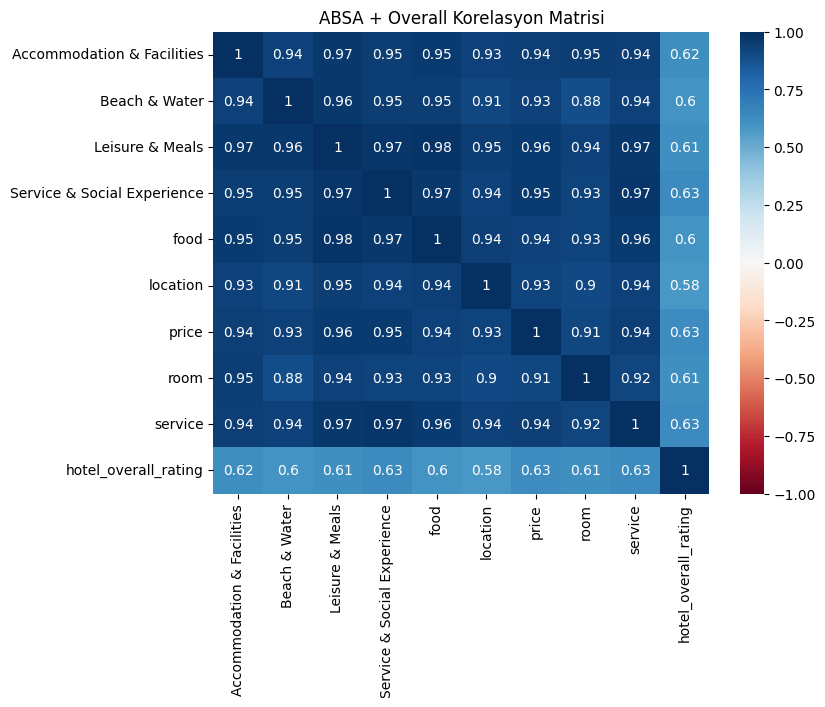

>>> 0.7 üzeri korelasyonlu feature çiftleri:
 Accommodation & Facilities   Beach & Water                  0.935029
                             Leisure & Meals                0.966806
                             Service & Social Experience    0.948839
                             food                           0.954559
                             location                       0.933012
                             price                          0.938854
                             room                           0.951459
                             service                        0.941335
Beach & Water                Leisure & Meals                0.964241
                             Service & Social Experience    0.950352
                             food                           0.945771
                             location                       0.907812
                             price                          0.930333
                             room                        

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection       import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model          import LogisticRegression
from sklearn.ensemble              import RandomForestClassifier
from sklearn.naive_bayes           import MultinomialNB
from sklearn.svm                   import LinearSVC
from xgboost                       import XGBClassifier

# --- 1) Veri ve Özellik Hazırlığı ---
df = pd.read_csv("C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv", encoding="utf-8-sig")
df = df.dropna(subset=["processed_final_review","review_rating","hotel_overall_rating"])
# Face score için (örnek Logistic’ten), ABSA’dan aldığımız pos_ratio’ları ve overall rating’i
# ABSA özetini önceden oluşturduğunuz "hotel_aspect_summary.csv" dosyasından yükleyelim:
absa = pd.read_csv("hotel_aspect_summary1.csv", encoding="utf-8-sig")
# absa: columns = ["hotel_name","aspect","pos_ratio"]

# Pivot ile her aspect’i ayrı sütuna alalım:
absa_piv = absa.pivot(index="hotel_name", columns="aspect", values="pos_ratio").fillna(0).reset_index()

# df_ml: yorum düzeyinde model için
df_ml = df.merge(absa_piv, on="hotel_name", how="left")

# X: hem metin hem numeric ABSA+overall
tf = TfidfVectorizer(min_df=2, max_df=0.8, ngram_range=(1,2))
X_text = tf.fit_transform(df_ml["processed_final_review"])
X_num  = df_ml[ list(absa_piv.columns.drop("hotel_name")) + ["hotel_overall_rating"] ].values

from scipy.sparse import hstack
X_all = hstack([X_text, X_num])

y = (df_ml["review_rating"]>=4).astype(int)

# --- 2) Korelasyon Matrisi ---
# Numeric kısmı alıp korelasyona bakalım:
num_df = pd.DataFrame(X_num, columns=list(absa_piv.columns.drop("hotel_name"))+["hotel_overall_rating"])
corr = num_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="RdBu", vmin=-1, vmax=1)
plt.title("ABSA + Overall Korelasyon Matrisi")
plt.show()

# Korelasyonu >0.7 olan çiftleri bul:
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .loc[lambda x: x.abs()>0.7]
)
print(">>> 0.7 üzeri korelasyonlu feature çiftleri:\n", high_corr)

# Eğer aşırı korelasyon varsa bu feature’lardan birini düşmelisiniz:
# örn: drops = ["some_aspect"]  sonra num_df = num_df.drop(columns=drops) vb.

# --- 3) K‐Fold Cross‐Validation (Stratified) ile Modelleri Karşılaştıralım ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "LinearSVC"         : LinearSVC(max_iter=2000),
    "NaiveBayes"        : MultinomialNB(),
    "XGBoost"           : XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

for name, mdl in models.items():
    scores = cross_val_score(mdl, X_all, y, cv=kf, scoring="accuracy", n_jobs=-1)
    print(f"{name:17} → Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

# İsterseniz precision/recall/f1 de bakabilirsiniz:
from sklearn.metrics import make_scorer, f1_score
f1_scorer = make_scorer(f1_score)
for name, mdl in models.items():
    f1 = cross_val_score(mdl, X_all, y, cv=kf, scoring=f1_scorer, n_jobs=-1)
    print(f"{name:17} → F1: {f1.mean():.3f} ± {f1.std():.3f}")

# --- 4) Train/Test Split + Final Evaluation ---
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y,
                                          test_size=0.2,
                                          stratify=y, random_state=42)
best = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
y_pred = best.predict(X_te)
from sklearn.metrics import classification_report
print("\n--- Final Test Set Report (LogisticRegression) ---")
print(classification_report(y_te, y_pred, target_names=["neg","pos"]))


>>> │r│ ≥ 0.7 olan aspect çiftleri:
 [('room_score', 'service_score', 0.8466027969111685), ('room_score', 'location_score', 0.8309315235444319), ('room_score', 'price_score', 0.7348957742840859), ('room_score', 'food_score', 0.839123945283399), ('service_score', 'location_score', 0.831023750195981), ('service_score', 'price_score', 0.8220648998400567), ('service_score', 'food_score', 0.8830330110254789), ('location_score', 'price_score', 0.7421934364975845), ('location_score', 'food_score', 0.8189755007773), ('price_score', 'food_score', 0.808746997007516)]

-> Otomatik atılan yüksek-korelasyonlu sütunlar: {'service_score', 'food_score', 'price_score', 'location_score'}


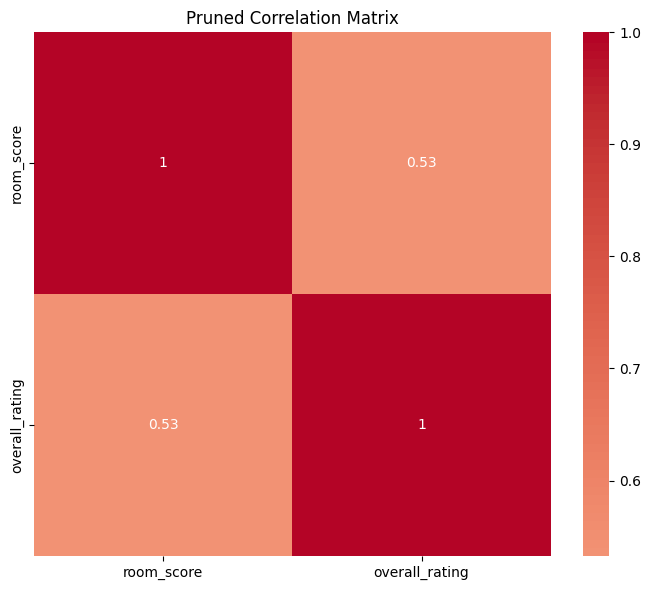


PCA(1) bileşeninin varyans oranı: [1.]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) CSV'den ABSA çıktısını oku
df = pd.read_csv("aspect_sentiment_results.csv", encoding="utf-8-sig")

# 2) Seed aspect'leri tanımla
seed_aspects = ['room', 'service', 'location', 'price', 'food']

# 3) JSON-string içinde dönen dict'i parse edip POS/NEG/NEUTRAL'u sayısala çevir
label_map = {'POSITIVE':  1,
             'NEGATIVE': -1,
             'NEUTRAL' :  0}

for asp in seed_aspects:
    # yeni numeric sütun:
    df[f"{asp}_score"] = df['aspect_sentiment'].apply(
        lambda x: (
            label_map.get(eval(x).get(asp, 'NEUTRAL'), 0)
            if isinstance(x, str) else
            label_map.get(x.get(asp, 'NEUTRAL'), 0)
        )
    )

# 4) Otel bazında ortalama aspect puanlarını al
hotel_scores = df.groupby('hotel_name')[[f"{asp}_score" for asp in seed_aspects]].mean()

# 5) Otellerin overall rating'ini ekle (review satırındaki hotel_overall_rating ortalaması)
hotel_overall = df.groupby('hotel_name')['hotel_overall_rating'].mean().rename('overall_rating')
hotel_scores = hotel_scores.merge(hotel_overall, left_index=True, right_index=True)

# 6) Korelasyon matrisini hesapla
corr = hotel_scores.corr()

# 7) │r│>=0.7 olan seed aspect çiftlerini bul ve aralarından birini drop etmeye karar ver
threshold = 0.7
# maskelenmiş (upper-triangle) korelasyon matrisi
mask = (abs(corr) >= threshold) & (abs(corr) < 1.0)
high_corr_pairs = [
    (i, j, corr.loc[i, j])
    for i in corr.index for j in corr.columns
    if mask.loc[i, j] and corr.columns.get_loc(j) > corr.index.get_loc(i)
]

print(">>> │r│ ≥ 0.7 olan aspect çiftleri:\n", high_corr_pairs)

# Örneğin hep j sütununu at:
to_drop = set(j for i, j, _ in high_corr_pairs)

print("\n-> Otomatik atılan yüksek-korelasyonlu sütunlar:", to_drop)

# Pruned dataframe
pruned = hotel_scores.drop(columns=to_drop)

# 8) Yeniden korelasyon matrisi ve görselleştirme
plt.figure(figsize=(7,6))
sns.heatmap(pruned.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Pruned Correlation Matrix")
plt.tight_layout()
plt.show()

# 9) isterseniz PCA ile kalan aspect'leri 1–2 bileşene indirebilirsiniz:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pruned['aspect_pca1'] = pca.fit_transform(pruned.drop(columns=['overall_rating']))
print("\nPCA(1) bileşeninin varyans oranı:", pca.explained_variance_ratio_)


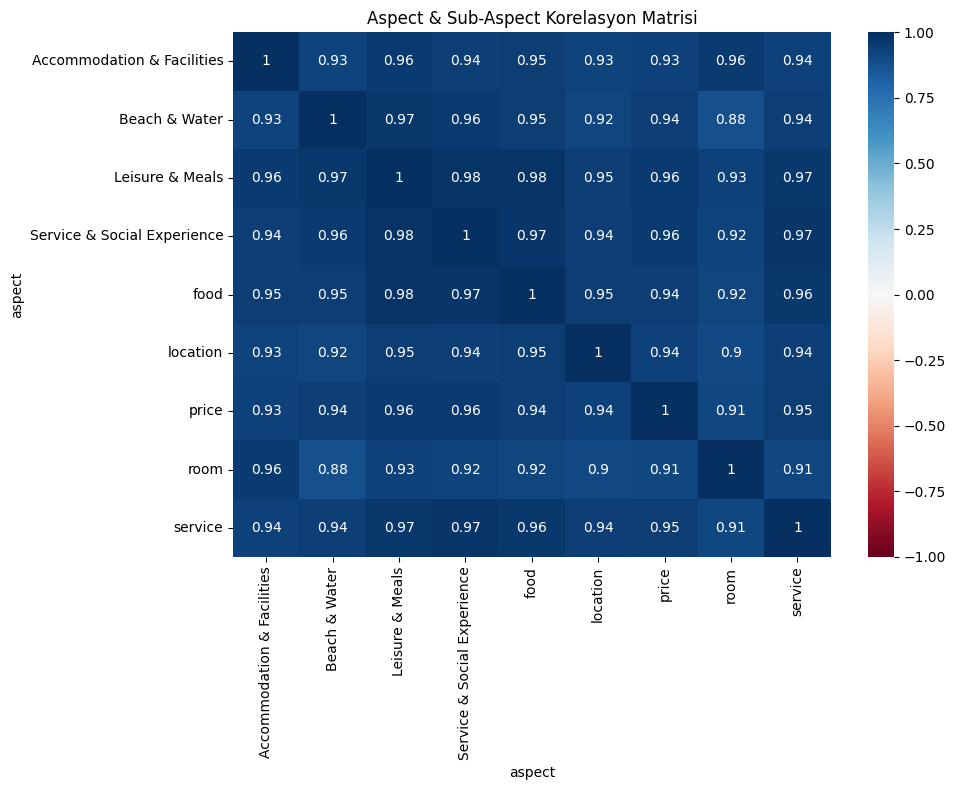

>>> |r| > 0.8 olan aspect çiftleri:
 aspect                       aspect                     
Leisure & Meals              food                           0.981888
                             Service & Social Experience    0.976955
Service & Social Experience  service                        0.971956
                             food                           0.971666
Leisure & Meals              service                        0.968170
Beach & Water                Leisure & Meals                0.968045
food                         service                        0.963332
Leisure & Meals              price                          0.960730
Service & Social Experience  price                          0.959647
Accommodation & Facilities   Leisure & Meals                0.958085
                             room                           0.956159
Beach & Water                Service & Social Experience    0.955076
Leisure & Meals              location                       0.952737
Beach & W

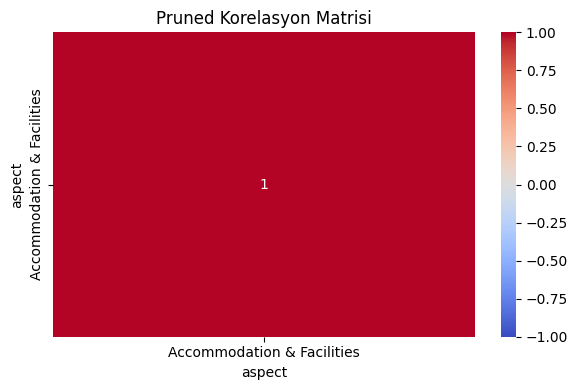

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Otel×Aspect pozitif-oran tablosunu oku
#    (ABSA’dan oluşturduğunuz summary CSV)
summary = pd.read_csv("hotel_aspect_summary1.csv", encoding="utf-8-sig")

# 2) Pivot yaparak her aspect’i ayrı sütuna taşı
wide = (
    summary
      .pivot(index="hotel_name", columns="aspect", values="pos_ratio")
      .fillna(0)
)

# 3) Eğer alt-aspect’leriniz ayrı bir CSV’deyse, onu da aynı mantıkla pivot’layın ve merge edin:
# sub = pd.read_csv("hotel_subaspect_summary.csv", ...)
# wide = wide.join(sub_pivot, how="left").fillna(0)

# 4) Korelasyon matrisini hesapla
corr = wide.corr()

# 5) Isı haritası
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="RdBu", vmin=-1, vmax=1)
plt.title("Aspect & Sub-Aspect Korelasyon Matrisi")
plt.tight_layout()
plt.show()

# 6) Eşik üstündeki çiftleri listele
threshold = 0.8
high = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .loc[lambda s: s.abs() > threshold]
        .sort_values(ascending=False)
)
print(f">>> |r| > {threshold} olan aspect çiftleri:\n", high)

# 7) Otomatik öneri: birinden vazgeçilecek sütunları çıkar
to_drop = {j for (i,j), v in high.items()}
print("\n📌 Önerilen drop listesi:", to_drop)

# 8) Pruned (düşürülmüş) matris ve tekrar korelasyon
pruned = wide.drop(columns=to_drop)
plt.figure(figsize=(6,4))
sns.heatmap(pruned.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pruned Korelasyon Matrisi")
plt.tight_layout()
plt.show()


C:\Users\catsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


ABSA:   0%|          | 0/1271 [00:00<?, ?it/s]

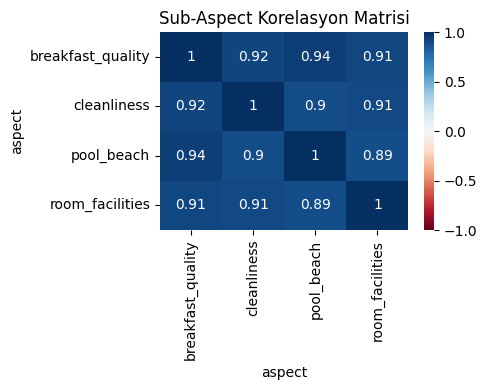

ValueError: Array conditional must be same shape as self

In [14]:
# ─── Tek Hücrede Çalıştır ───────────────────────────────────────────────────
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv

# 1) Sub‐aspect’ler
sub_aspects = [
    "pool_beach",         # sahil/havuz deneyimi
    "breakfast_quality",  # kahvaltı kalitesi
    "cleanliness",        # temizlik & banyo tesisleri
    "room_facilities"     # oda/apartman olanakları
]

# 2) Veriyi yükle
df = pd.read_csv(
    "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv",
    encoding="utf-8-sig"
)
df = df.dropna(subset=["processed_final_review","hotel_name"]).reset_index(drop=True)

# 3) ABSA modeli
MODEL = "yangheng/deberta-v3-base-absa-v1.1"
device    = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL).to(device)

# 4) Her yorum × alt‐aspect için sentiment tahmini
records = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="ABSA"):
    review = row["processed_final_review"]
    hotel  = row["hotel_name"]
    for aspect in sub_aspects:
        enc   = tokenizer(review, aspect, return_tensors="pt",
                          truncation=True, max_length=256).to(device)
        out   = model(**enc)
        probs = F.softmax(out.logits[0], dim=-1)
        lab   = torch.argmax(probs).item()
        label = model.config.id2label[lab].lower()
        records.append({
            "hotel_name": hotel,
            "aspect":     aspect,
            "sentiment":  label
        })

# 5) DataFrame’e dök
df_sub = pd.DataFrame(records)

# 6) CSV’ye manuel yaz (pandas.to_csv hatasını atlatmak için)
with open("all_reviews_subaspect_sentiments.csv", "w", encoding="utf-8-sig", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["hotel_name","aspect","sentiment"])
    writer.writeheader()
    writer.writerows(df_sub.to_dict("records"))

# 7) Otel × alt‐aspect pozitif oranı
df_sub["is_positive"] = (df_sub.sentiment=="positive").astype(int)
hotel_sub_summary = (
    df_sub
      .groupby(["hotel_name","aspect"])["is_positive"]
      .mean()
      .reset_index()
      .rename(columns={"is_positive":"pos_ratio"})
)

# 8) Yine manuel CSV
with open("hotel_subaspect_summary.csv", "w", encoding="utf-8-sig", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["hotel_name","aspect","pos_ratio"])
    writer.writeheader()
    writer.writerows(hotel_sub_summary.to_dict("records"))

# 9) Korelasyon matrisi
sub_df = hotel_sub_summary.pivot(index="hotel_name",
                                 columns="aspect",
                                 values="pos_ratio").fillna(0)

plt.figure(figsize=(5,4))
sns.heatmap(sub_df.corr(), annot=True, cmap="RdBu", vmin=-1, vmax=1)
plt.title("Sub-Aspect Korelasyon Matrisi")
plt.tight_layout()
plt.show()

high_corr = (
    sub_df.corr()
          .where(np.triu(np.ones(sub_df.shape), k=1).astype(bool))
          .stack()
          .loc[lambda x: x.abs()>0.8]
)
print("\n>>> |r| > 0.8 sub-aspect çiftleri:\n", high_corr)
# ────────────────────────────────────────────────────────────────────────────────


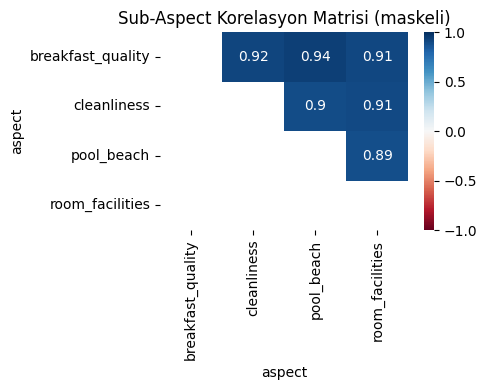


>>> |r| > 0.8 sub-aspect çiftleri:
 aspect             aspect         
breakfast_quality  cleanliness        0.919536
                   pool_beach         0.940640
                   room_facilities    0.912073
cleanliness        pool_beach         0.897280
                   room_facilities    0.906066
pool_beach         room_facilities    0.889117
dtype: float64

PCA(1) explained variance ratio: 0.933

Final korelasyon:
                      subaspect_pca1  hotel_overall_rating
subaspect_pca1              1.000000             -0.644319
hotel_overall_rating       -0.644319              1.000000


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1) sub‐aspect summary CSV’sini oku
hotel_sub = pd.read_csv("hotel_subaspect_summary.csv", encoding="utf-8-sig")
# pivot: otel × sub_aspect matrix
sub_df = hotel_sub.pivot(
    index="hotel_name",
    columns="aspect",
    values="pos_ratio"
).fillna(0)

# 2) Korelasyon matrisi ve maskeyle üst üçgen
corr = sub_df.corr()
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

plt.figure(figsize=(5,4))
sns.heatmap(corr, mask=~mask, annot=True, cmap="RdBu", vmin=-1, vmax=1)
plt.title("Sub-Aspect Korelasyon Matrisi (maskeli)")
plt.tight_layout()
plt.show()

# 3) |r|>0.8 olan çiftler
high_corr = (
    corr.where(mask)      # yalnızca üst üçgen
        .stack()          # long format
        .loc[lambda x: x.abs()>0.8]
)
print("\n>>> |r| > 0.8 sub-aspect çiftleri:\n", high_corr)

# 4) PCA ile tek bileşene indir
pca = PCA(n_components=1)
sub_df["subaspect_pca1"] = pca.fit_transform(sub_df)
print(f"\nPCA(1) explained variance ratio: {pca.explained_variance_ratio_[0]:.3f}")

# 5) Yeni korelasyon (özellikle overall_rating ile)
#    Önce overall_rating'i ekleyelim:
overall = pd.read_csv("C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv",
                      encoding="utf-8-sig")[["hotel_name","hotel_overall_rating"]]
overall = overall.groupby("hotel_name").mean()

df_final = sub_df[["subaspect_pca1"]].merge(overall, left_index=True, right_index=True)
print("\nFinal korelasyon:")
print(df_final.corr())

# 6) Eğer ML modelinize sokacaksanız artık yalnızca 'subaspect_pca1' ile devam edin:
#    X_num = df_final["subaspect_pca1"].values.reshape(-1,1)
#    ... vs.



In [7]:
import pandas as pd
from sklearn.decomposition import PCA

# 1) Sub‐aspect özet CSV’sini oku
#    Bu dosya daha önce “hotel_subaspect_summary.csv” olarak oluşturulmuş olmalı:
#    columns = [hotel_name, aspect, pos_ratio]
sub = pd.read_csv("hotel_subaspect_summary.csv", encoding="utf-8-sig")

# 2) Otel × sub‐aspect pivot
sub_df = (
    sub
    .pivot(index="hotel_name", columns="aspect", values="pos_ratio")
    .fillna(0)
)

# 3) Orijinal yorum CSV’sinden otel genel puan ortalamasını al
df = pd.read_csv(
    "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv",
    encoding="utf-8-sig"
)
overall = (
    df
    .dropna(subset=["hotel_name","hotel_overall_rating"])
    .groupby("hotel_name")["hotel_overall_rating"]
    .mean()
    .rename("overall_rating")
)

# 4) Birleştir
sub_df = sub_df.merge(overall, left_index=True, right_index=True)

# 5) PCA ile sub‐aspect’leri tek bileşene indir
pca = PCA(n_components=1, random_state=42)
sub_df["subaspect_pca1"] = pca.fit_transform(sub_df.drop(columns=["overall_rating"]))

print(f"📊 PCA(1) explained variance ratio: {pca.explained_variance_ratio_[0]:.3f}")

# 6) Dosyayı kaydet
sub_df.to_csv("hotel_subaspect_and_pca.csv", index=True, encoding="utf-8-sig")
print("✅ 'hotel_subaspect_and_pca.csv' oluşturuldu.")


📊 PCA(1) explained variance ratio: 0.933
✅ 'hotel_subaspect_and_pca.csv' oluşturuldu.


In [9]:
import pandas as pd
import numpy as np

from sklearn.decomposition        import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse               import hstack
from sklearn.model_selection    import StratifiedKFold, cross_val_score
from sklearn.linear_model       import LogisticRegression

# 1) Load your sub‐aspect + overall‐rating csv
#    (this CSV must have columns: hotel_name, subaspect_pca1, overall_rating)
sub_df = pd.read_csv("hotel_subaspect_and_pca.csv", index_col="hotel_name")

# 2) Load your review‐level data
df = pd.read_csv("C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv", encoding="utf-8-sig")
df = df.dropna(subset=["processed_final_review","review_rating","hotel_name"])

# 3) Prepare y and review texts
reviews = df["processed_final_review"].tolist()
y       = (df["review_rating"] >= 4).astype(int).values

# 4) Build your numeric matrix (align by hotel_name)
#    Join df.hotel_name → sub_df index
num_df = (
    df[["hotel_name"]]
      .merge(sub_df, on="hotel_name", how="left")
      .fillna(0)    # in case some hotels are missing
)
X_num = num_df[["subaspect_pca1","overall_rating"]].values

# 5) TF-IDF on texts
tfidf  = TfidfVectorizer(min_df=2, max_df=0.8, ngram_range=(1,2))
X_text = tfidf.fit_transform(reviews)

# 6) Stack text + numeric
X_all = hstack([X_text, X_num])

# 7) 5-fold Stratified CV with LogisticRegression
kf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model  = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X_all, y, cv=kf, scoring="accuracy", n_jobs=-1)

print(f"LogisticRegression Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")


LogisticRegression Accuracy: 0.857 ± 0.024



=== LogisticRegression ===
Accuracy: 0.857 ± 0.024
F1-score: 0.911 ± 0.014
Classification Report:
              precision    recall  f1-score   support

         neg       0.83      0.52      0.64       309
         pos       0.86      0.97      0.91       959

    accuracy                           0.86      1268
   macro avg       0.85      0.74      0.77      1268
weighted avg       0.85      0.86      0.84      1268



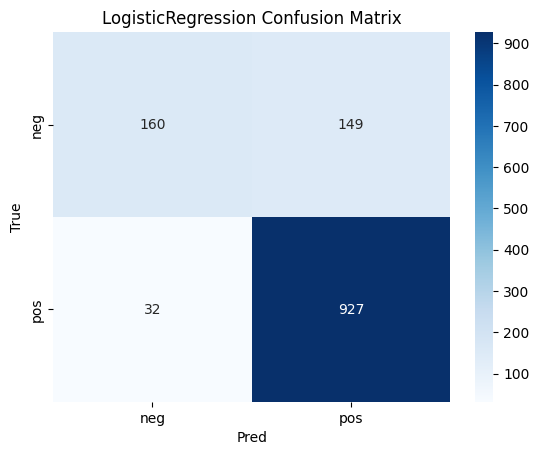


=== RandomForest ===
Accuracy: 0.879 ± 0.019
F1-score: 0.926 ± 0.011
Classification Report:
              precision    recall  f1-score   support

         neg       0.97      0.52      0.68       309
         pos       0.87      0.99      0.93       959

    accuracy                           0.88      1268
   macro avg       0.92      0.76      0.80      1268
weighted avg       0.89      0.88      0.87      1268



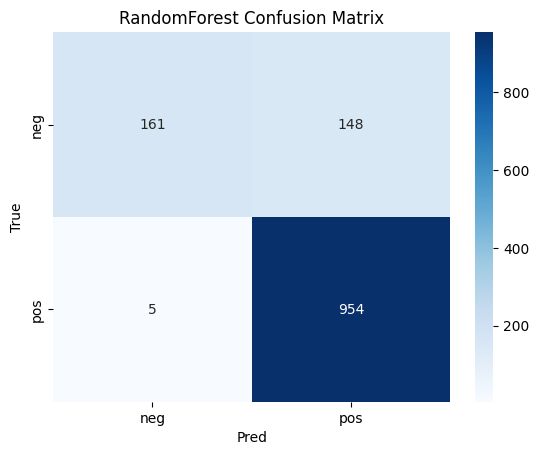


=== LinearSVC ===
Accuracy: 0.913 ± 0.023
F1-score: 0.945 ± 0.014
Classification Report:
              precision    recall  f1-score   support

         neg       0.92      0.71      0.80       309
         pos       0.91      0.98      0.94       959

    accuracy                           0.91      1268
   macro avg       0.92      0.84      0.87      1268
weighted avg       0.91      0.91      0.91      1268



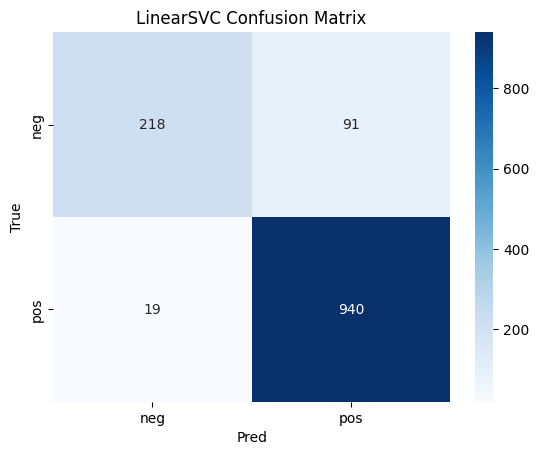


=== NaiveBayes ===


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\catsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\catsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\catsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\naive_bayes.py", line 772, in fit
    self._count(X, Y)
  File "C:\Users\catsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sk

In [10]:
import pandas as pd
import numpy as np
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns

# modeller & metrikler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection       import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.linear_model          import LogisticRegression
from sklearn.ensemble              import RandomForestClassifier
from sklearn.naive_bayes           import MultinomialNB
from sklearn.svm                   import LinearSVC
from xgboost                       import XGBClassifier
from sklearn.metrics               import classification_report, confusion_matrix

# 1) Yorum verisi + subaspect&PCA + overall puan
df_rev = pd.read_csv(
    "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv",
    encoding="utf-8-sig"
)[["hotel_name","processed_final_review","review_rating"]].dropna()

# 2) Otel-subaspect&PCA & overall
df_num = pd.read_csv("hotel_subaspect_and_pca.csv", index_col="hotel_name", encoding="utf-8-sig")

# 3) Merge
df = df_rev.merge(df_num.reset_index(), on="hotel_name", how="left").dropna(subset=["subaspect_pca1","overall_rating"])

# 4) X_text, X_num, y
tf = TfidfVectorizer(min_df=2, max_df=0.8, ngram_range=(1,2))
X_text = tf.fit_transform(df["processed_final_review"])

X_num = df[["subaspect_pca1","overall_rating"]].values
X_all = hstack([X_text, X_num])

y = (df["review_rating"] >= 4).astype(int)

# 5) Modelleri tanımla
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "LinearSVC"         : LinearSVC(max_iter=2000),
    "NaiveBayes"        : MultinomialNB(),
    "XGBoost"           : XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, mdl in models.items():
    print(f"\n=== {name} ===")
    # cross‐val accuracy
    acc = cross_val_score(mdl, X_all, y, cv=kf, scoring="accuracy", n_jobs=-1)
    print(f"Accuracy: {acc.mean():.3f} ± {acc.std():.3f}")
    # cross‐val f1
    f1  = cross_val_score(mdl, X_all, y, cv=kf, scoring="f1", n_jobs=-1)
    print(f"F1-score: {f1.mean():.3f} ± {f1.std():.3f}")
    # cross‐val predict for confusion + classification_report
    y_pred = cross_val_predict(mdl, X_all, y, cv=kf, n_jobs=-1)
    print("Classification Report:")
    print(classification_report(y, y_pred, target_names=["neg","pos"]))
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["neg","pos"], yticklabels=["neg","pos"])
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.show()


In [5]:
# Full end-to-end Jupyter script: Seed–Aspect ABSA → Prune → ML Pipeline

# %% [markdown]
# # 1) Setup & Seed-Aspects

# %%
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.feature_extraction.text  import TfidfVectorizer
from sklearn.model_selection           import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model              import LogisticRegression
from sklearn.ensemble                  import RandomForestClassifier
from sklearn.naive_bayes               import MultinomialNB
from sklearn.svm                       import LinearSVC
from xgboost                           import XGBClassifier
from sklearn.metrics                   import classification_report, make_scorer, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Seed-aspects (only these five)
seed_aspects = {
    "room":    ["room","floor","bedroom","bathroom","kitchen","balcony","bed","apartment","desk","hall","laundry","sofa","basement","spacious"],
    "service": ["service","staff","customer","maintenance","internet","support","quality","cleanliness","reliable"],
    "location":["location","proximity","area","destination","vicinity","distance","close","parking"],
    "price":   ["price","cost","value","discount","affordable","expensive","pay","worth"],
    "food":    ["food","meal","restaurant","breakfast","lunch","dinner","soup","pizza","bread","coffee","dessert"]
}
aspect_names = list(seed_aspects.keys())

# %% [markdown]
# # 2) Load Data & ABSA Prediction (seed-only)

# %%
# 2.1) Read reviews
df = pd.read_csv("C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv", encoding="utf-8-sig")
df = df.dropna(subset=["processed_final_review"]).reset_index(drop=True)

# 2.2) Load ABSA model
MODEL = "yangheng/deberta-v3-base-absa-v1.1"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL)
device    = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# 2.3) ABSA prediction function
def predict_sentiment(review: str, aspect: str) -> str:
    inputs = tokenizer(review, aspect,
                       return_tensors="pt", truncation=True, max_length=256).to(device)
    out    = model(**inputs)
    scores = F.softmax(out.logits[0], dim=-1)  # [neg, neu, pos]
    label  = torch.argmax(scores).item()
    return model.config.id2label[label].lower()

# 2.4) Loop over reviews × aspects
records = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="ABSA seed-only"):
    review = row["processed_final_review"]
    hotel  = row.get("hotel_name","")
    for asp in aspect_names:
        sent = predict_sentiment(review, asp)
        records.append((hotel, idx, asp, sent))

absa_df = pd.DataFrame(records, columns=["hotel_name","review_idx","aspect","sentiment"])
absa_df.to_csv("absa_seed_only.csv", index=False, encoding="utf-8-sig")
print("✅ ABSA (seed-only) saved → absa_seed_only.csv")

# %% [markdown]
# # 3) Hotel × Aspect “Positive Ratio” Summary

# %%
absa = pd.read_csv("absa_seed_only.csv", encoding="utf-8-sig")
absa["is_positive"] = (absa.sentiment=="positive")
summary = (
    absa.groupby(["hotel_name","aspect"])["is_positive"]
         .mean()
         .reset_index()
         .rename(columns={"is_positive":"pos_ratio"})
)
summary.to_csv("hotel_seed_aspect_summary.csv", index=False, encoding="utf-8-sig")
print("✅ Summary saved → hotel_seed_aspect_summary.csv")

# %% [markdown]
# # 4) Correlation & Pruning (drop |r|>0.7)

# %%
# 4.1) Merge with overall rating
overall = df[["hotel_name","hotel_overall_rating"]].drop_duplicates()
df_num = summary.merge(overall, on="hotel_name", how="left")

# 4.2) Pivot to wide
pivot = df_num.pivot(index="hotel_name", columns="aspect", values="pos_ratio")
num_df = pivot.join(overall.set_index("hotel_name"))

# 4.3) Compute absolute correlation
corr = num_df.corr().abs()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="RdBu", vmin=0, vmax=1)
plt.title("Seed-Aspect + Overall Rating Correlation")
plt.show()

# 4.4) Find |r|>0.7 pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high  = [(i,j,upper.loc[i,j]) for i in upper.columns for j in upper.columns
          if pd.notna(upper.loc[i,j]) and upper.loc[i,j]>0.7]
print(">>> |r|>0.7 pairs:", high)

# 4.5) Drop lower-variance features
to_drop = set()
for i,j,r in high:
    vi, vj = num_df[i].var(), num_df[j].var()
    to_drop.add(i if vi<vj else j)
print("Drop these aspects:", to_drop)

pruned = num_df.drop(columns=to_drop)
pruned.to_csv("pruned_numeric.csv", index=False, encoding="utf-8-sig")
print("✅ Pruned numeric saved → pruned_numeric.csv")

# %% [markdown]
# # 5) ML Pipeline: TF-IDF + Pruned Numeric Features

# %%
# 5.1) Load original text + pruned numeric
df_text = pd.read_csv("C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv", encoding="utf-8-sig")
df_text = df_text.dropna(subset=["processed_final_review","review_rating","hotel_overall_rating"]).reset_index(drop=True)
absa_sum = pd.read_csv("hotel_seed_aspect_summary.csv", encoding="utf-8-sig")
absa_piv = absa_sum.pivot(index="hotel_name", columns="aspect", values="pos_ratio").fillna(0).reset_index()
df_ml    = df_text.merge(absa_piv, on="hotel_name", how="left")

# 5.2) Features & target
tfidf    = TfidfVectorizer(min_df=2, max_df=0.8, ngram_range=(1,2))
X_text   = tfidf.fit_transform(df_ml["processed_final_review"])

# numeric: only pruned aspects + overall_rating
num_cols = [c for c in pruned.columns if c!="hotel_name"]
X_num    = df_ml[num_cols].values

from scipy.sparse import hstack
X_all    = hstack([X_text, X_num])

y        = (df_ml["review_rating"]>=4).astype(int)

# 5.3) 5-fold CV comparison
kf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "LinearSVC"         : LinearSVC(max_iter=2000),
    "NaiveBayes"        : MultinomialNB(),
    "XGBoost"           : XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

print("=== CV Accuracy ===")
for name,mdl in models.items():
    acc = cross_val_score(mdl, X_all, y, cv=kf, scoring="accuracy", n_jobs=-1)
    print(f"{name:17} → {acc.mean():.3f} ± {acc.std():.3f}")

f1_scorer = make_scorer(f1_score)
print("\n=== CV F1 ===")
for name,mdl in models.items():
    f1 = cross_val_score(mdl, X_all, y, cv=kf, scoring=f1_scorer, n_jobs=-1)
    print(f"{name:17} → {f1.mean():.3f} ± {f1.std():.3f}")

# 5.4) Final train/test with LogisticRegression
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y,
                                          test_size=0.2,
                                          stratify=y, random_state=42)
best = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
y_pred = best.predict(X_te)

print("\n=== Final Test Set (LogisticRegression) ===")
print(classification_report(y_te, y_pred, target_names=["neg","pos"]))


C:\Users\catsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
ABSA seed-only: 100%|██████████████████████████████████████████████████████████████| 1271/1271 [29:22<00:00,  1.39s/it]


✅ ABSA (seed-only) saved → absa_seed_only.csv
✅ Summary saved → hotel_seed_aspect_summary.csv


ValueError: Index contains duplicate entries, cannot reshape

C:\Users\catsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
ABSA seed-only: 100%|██████████████████████████████████████████████████████████████| 1271/1271 [30:38<00:00,  1.45s/it]


✅ ABSA (seed-only) saved → absa_seed_only.csv
✅ Summary saved → hotel_seed_aspect_summary.csv


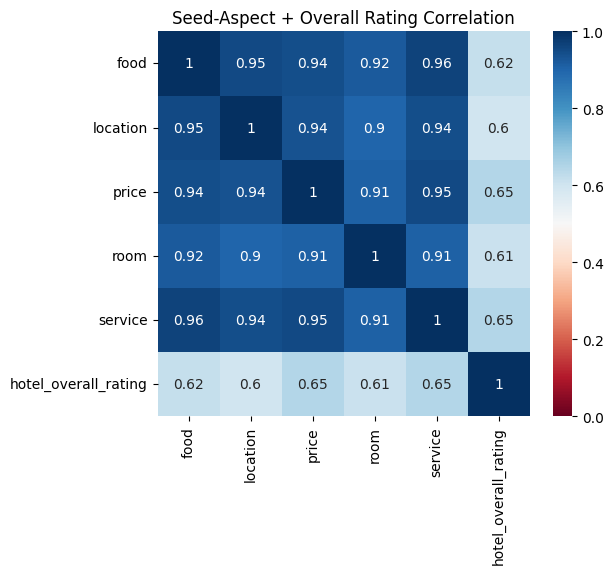

>>> |r|>0.7 pairs: [('food', 'location', 0.950599898087204), ('food', 'price', 0.9433578933039188), ('food', 'room', 0.9217659998844895), ('food', 'service', 0.9635690572409271), ('location', 'price', 0.9360364492836488), ('location', 'room', 0.9017484709756235), ('location', 'service', 0.9421229019208107), ('price', 'room', 0.9082890078895712), ('price', 'service', 0.9496120781640993), ('room', 'service', 0.9100713330991382)]
Drop these aspects: {'service', 'price', 'location', 'food'}
✅ Pruned numeric saved → pruned_numeric.csv


ValueError: list.remove(x): x not in list

In [6]:
# Full end-to-end Jupyter pipeline: Seed-aspect ABSA → Prune features → ML evaluation

# %% [markdown]
# ## 1) Setup & Seed-Aspects

# %%
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.feature_extraction.text  import TfidfVectorizer
from sklearn.model_selection           import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model              import LogisticRegression
from sklearn.ensemble                  import RandomForestClassifier
from sklearn.naive_bayes               import MultinomialNB
from sklearn.svm                       import LinearSVC
from xgboost                           import XGBClassifier
from sklearn.metrics                   import classification_report, make_scorer, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Only these five seed aspects
seed_aspects = {
    "room":    ["room","floor","bedroom","bathroom","kitchen","balcony","bed","apartment","desk","hall","laundry","sofa","basement","spacious"],
    "service": ["service","staff","customer","maintenance","internet","support","quality","cleanliness","reliable"],
    "location":["location","proximity","area","destination","vicinity","distance","close","parking"],
    "price":   ["price","cost","value","discount","affordable","expensive","pay","worth"],
    "food":    ["food","meal","restaurant","breakfast","lunch","dinner","soup","pizza","bread","coffee","dessert"]
}
aspect_names = list(seed_aspects.keys())

# %% [markdown]
# ## 2) Load Reviews & ABSA (seed-only)

# %%
# 2.1) Read reviews
df = pd.read_csv("C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv", encoding="utf-8-sig")
df = df.dropna(subset=["processed_final_review"]).reset_index(drop=True)

# 2.2) Load pretrained ABSA model
MODEL = "yangheng/deberta-v3-base-absa-v1.1"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL)
device    = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# 2.3) Prediction helper
def predict_sentiment(review: str, aspect: str) -> str:
    inputs = tokenizer(review, aspect,
                       return_tensors="pt", truncation=True, max_length=256).to(device)
    out    = model(**inputs)
    scores = F.softmax(out.logits[0], dim=-1)  # [neg, neu, pos]
    label  = torch.argmax(scores).item()
    return model.config.id2label[label].lower()

# 2.4) Run ABSA for each review × seed aspect
records = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="ABSA seed-only"):
    rev   = row["processed_final_review"]
    hotel = row.get("hotel_name","")
    for asp in aspect_names:
        sent = predict_sentiment(rev, asp)
        records.append((hotel, idx, asp, sent))

absa_df = pd.DataFrame(records, columns=["hotel_name","review_idx","aspect","sentiment"])
absa_df.to_csv("absa_seed_only.csv", index=False, encoding="utf-8-sig")
print("✅ ABSA (seed-only) saved → absa_seed_only.csv")

# %% [markdown]
# ## 3) Hotel-Aspect Positive Ratio Summary

# %%
absa = pd.read_csv("absa_seed_only.csv", encoding="utf-8-sig")
absa["is_positive"] = (absa.sentiment=="positive")
summary = (
    absa.groupby(["hotel_name","aspect"])["is_positive"]
         .mean()
         .reset_index()
         .rename(columns={"is_positive":"pos_ratio"})
)
summary.to_csv("hotel_seed_aspect_summary.csv", index=False, encoding="utf-8-sig")
print("✅ Summary saved → hotel_seed_aspect_summary.csv")

# %% [markdown]
# ## 4) Correlation & Pruning

# %%
# 4.1) Merge summary with overall rating
overall = df[["hotel_name","hotel_overall_rating"]].drop_duplicates()
df_num  = summary.merge(overall, on="hotel_name", how="left")

# 4.2) Pivot using pivot_table to avoid duplicates
pivot   = df_num.pivot_table(
    index="hotel_name",
    columns="aspect",
    values="pos_ratio",
    aggfunc="mean"
)
num_df  = pivot.join(overall.set_index("hotel_name"))

# 4.3) Plot correlation heatmap
corr = num_df.corr().abs()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="RdBu", vmin=0, vmax=1)
plt.title("Seed-Aspect + Overall Rating Correlation")
plt.show()

# 4.4) Identify |r|>0.7 pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high  = [(i,j,upper.loc[i,j]) for i in upper.columns for j in upper.columns
          if pd.notna(upper.loc[i,j]) and upper.loc[i,j]>0.7]
print(">>> |r|>0.7 pairs:", high)

# 4.5) Decide which to drop (drop lower-variance)
to_drop = set()
for i,j,r in high:
    if num_df[i].var() < num_df[j].var():
        to_drop.add(i)
    else:
        to_drop.add(j)
print("Drop these aspects:", to_drop)

pruned = num_df.drop(columns=to_drop)
pruned.to_csv("pruned_numeric.csv", index=False, encoding="utf-8-sig")
print("✅ Pruned numeric saved → pruned_numeric.csv")

# %% [markdown]
# ## 5) ML Pipeline: TF-IDF + Pruned Numeric

# %%
# 5.1) Prepare text + numeric features
df_text = pd.read_csv("C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv", encoding="utf-8-sig")
df_text = df_text.dropna(subset=["processed_final_review","review_rating","hotel_overall_rating"]).reset_index(drop=True)
absa_sum= pd.read_csv("hotel_seed_aspect_summary.csv", encoding="utf-8-sig")
absa_piv= absa_sum.pivot(index="hotel_name", columns="aspect", values="pos_ratio").fillna(0).reset_index()
df_ml   = df_text.merge(absa_piv, on="hotel_name", how="left")

tfidf   = TfidfVectorizer(min_df=2, max_df=0.8, ngram_range=(1,2))
X_text  = tfidf.fit_transform(df_ml["processed_final_review"])

num_cols= pruned.columns.tolist()  # includes overall_rating + kept aspects
num_cols.remove("hotel_name")
X_num   = df_ml[num_cols].values

from scipy.sparse import hstack
X_all   = hstack([X_text, X_num])

y       = (df_ml["review_rating"]>=4).astype(int)

# 5.2) 5-fold CV comparison
kf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "LinearSVC"         : LinearSVC(max_iter=2000),
    "NaiveBayes"        : MultinomialNB(),
    "XGBoost"           : XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

print("=== CV Accuracy ===")
for name,mdl in models.items():
    scores = cross_val_score(mdl, X_all, y, cv=kf, scoring="accuracy", n_jobs=-1)
    print(f"{name:17} → {scores.mean():.3f} ± {scores.std():.3f}")

f1_scorer = make_scorer(f1_score)
print("\n=== CV F1 ===")
for name,mdl in models.items():
    scores = cross_val_score(mdl, X_all, y, cv=kf, scoring=f1_scorer, n_jobs=-1)
    print(f"{name:17} → {scores.mean():.3f} ± {scores.std():.3f}")

# 5.3) Final train/test with LogisticRegression
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y,
                                          test_size=0.2,
                                          stratify=y, random_state=42)
best = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
y_pred = best.predict(X_te)

print("\n=== Final Test Set (LogisticRegression) ===")
print(classification_report(y_te, y_pred, target_names=["neg","pos"]))


In [2]:
import pandas as pd
import numpy as np

# 1) ABSA summary’i oku
#    kolonlar: hotel_name, aspect, pos_ratio
absa = pd.read_csv("hotel_aspect_summary1.csv", encoding="utf-8-sig")

# 2) Pivot: her aspect bir sütun, eksikler 0 ile doldur
pivot = (
    absa
    .pivot(index="hotel_name", columns="aspect", values="pos_ratio")
    .fillna(0)
)

# 3) Korelasyon matrisini hesapla
corr = pivot.corr()

# 4) |r| > 0.7 olan çiftleri bul
high_corr = (
    corr
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .loc[lambda x: x.abs() > 0.7]
    .sort_values(ascending=False)
)

print(">>> 0.7 üzeri korelasyonlu aspect çiftleri:\n")
print(high_corr, "\n")

# 5) Otomatik prune: her çiftten ikinciyi drop et
to_drop = set()
for (a1, a2), r in high_corr.items():
    # eğer a2 hâlâ drop listesinde yoksa ekle
    if a2 not in to_drop:
        to_drop.add(a2)

print("✅ Otomatik olarak atılacak aspect’ler:", to_drop, "\n")

# 6) Kalan aspect’ler
keep = [c for c in pivot.columns if c not in to_drop]
print("🎯 Keep aspects:", keep)


>>> 0.7 üzeri korelasyonlu aspect çiftleri:

aspect                       aspect                     
Leisure & Meals              food                           0.981888
                             Service & Social Experience    0.976955
Service & Social Experience  service                        0.971956
                             food                           0.971666
Leisure & Meals              service                        0.968170
Beach & Water                Leisure & Meals                0.968045
food                         service                        0.963332
Leisure & Meals              price                          0.960730
Service & Social Experience  price                          0.959647
Accommodation & Facilities   Leisure & Meals                0.958085
                             room                           0.956159
Beach & Water                Service & Social Experience    0.955076
Leisure & Meals              location                       0.952737
B

In [6]:
import pandas as pd
import numpy as np

# 1) Manuel tanımlı tüm aspect’leriniz
aspects = {
    # 5 Seed
    "room":               ["room","floor","bedroom","bathroom","kitchen","balcony","bed","apartment","desk","hall","laundry","sofa","basement","spacious"],
    "service":            ["service","staff","customer","maintenance","internet","support","quality","cleanliness","reliable"],
    "location":           ["location","proximity","area","destination","vicinity","distance","close","parking"],
    "price":              ["price","cost","value","discount","affordable","expensive","pay","worth"],
    "food":               ["food","meal","restaurant","breakfast","lunch","dinner","soup","pizza","bread","coffee","dessert"],
    # 3 Discovered
    "Beach & Water":      ["beach","sea","water","pool"],
    "Accommodation & Facilities": ["bathroom","shower","apartment","hotel","location"],
    "Service & Social Experience": ["staff","place","family","people","night","problem","river","price"],
    "Leisure & Meals":    ["breakfast","beach","holiday"],
    "Facilities & Cleanliness": ["bathroom","shower","toilet","towel","door","cleanliness"]
}
aspect_names = list(aspects.keys())

# 2) ABSA özet CSV’nizi yükleyin
#    CSV’de: hotel_name, aspect, pos_ratio
summary = pd.read_csv("hotel_aspect_summary1.csv", encoding="utf-8-sig")
# Sadece tanımlı aspect’leri al
summary = summary[summary.aspect.isin(aspect_names)]

# 3) Pivot → hotel × aspect matrisi
pivot = summary.pivot(index="hotel_name", columns="aspect", values="pos_ratio").fillna(0)

# 4) Mutlak korelasyon matrisi
corr = pivot.corr().abs()

# 5) |r| > 0.7 olan aspect çiftlerini bulun
high = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .loc[lambda x: x>0.7]
)
print("🛑 0.7 üzeri korelasyonlu çiftler:\n", high, "\n")

# 6) Her yüksek-korelasyonlu çiftten varyansı daha düşük olanda işaret koyup düşür
to_drop = set()
vars_ = pivot.var()
for (a, b), r in high.items():
    # hangi feature daha düşük varyanslıysa onu drop et
    drop = a if vars_[a] < vars_[b] else b
    to_drop.add(drop)

print("🔻 Otomatik düşürülen aspect’ler:", to_drop, "\n")

# 7) Finalde kalan, ML’e girecek aspect’ler:
final_aspects = [a for a in aspect_names if a not in to_drop]
print("✅ Final kept aspects:", final_aspects)


🛑 0.7 üzeri korelasyonlu çiftler:
 aspect                       aspect                     
Accommodation & Facilities   Beach & Water                  0.929625
                             Leisure & Meals                0.958085
                             Service & Social Experience    0.941467
                             food                           0.948193
                             location                       0.928710
                             price                          0.933524
                             room                           0.956159
                             service                        0.935240
Beach & Water                Leisure & Meals                0.968045
                             Service & Social Experience    0.955076
                             food                           0.951076
                             location                       0.917732
                             price                          0.937845
           

In [9]:
# %%python
import pandas as pd
import numpy as np

# 1) ABSA özetini yükle ve pivot et
#    hotel_aspect_summary.csv: sütunlar = ["hotel_name","aspect","pos_ratio"]
df = pd.read_csv("hotel_aspect_summary1.csv", encoding="utf-8-sig")
pivot = (
    df
    .pivot(index="hotel_name", columns="aspect", values="pos_ratio")
    .fillna(0)
)

# 2) Korelasyon matrisi → |r| > 0.8 eşiğiyle bak
corr = pivot.corr().abs()
high_corr = (
    corr
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .loc[lambda x: x > 0.8]
)
print("⚠️ 0.8 üzeri korelasyonlu aspect çiftleri:\n", high_corr, "\n")

# 3) Hangilerini drop edelim?
#    Birbirleriyle fazla korele olan iki feature’dan, 
#    varyansı daha düşük (daha düz seyreden) olana veda ediyoruz:
vars_ = pivot.var()
to_drop = set()
for (a, b), r in high_corr.items():
    # daha düşük varyanslıyı drop et
    drop = a if vars_[a] < vars_[b] else b
    to_drop.add(drop)

print("🔻 Otomatik düşürülecek aspect’ler:", to_drop)
kept = [c for c in pivot.columns if c not in to_drop]
print("✅ Kalan aspect’ler:", kept)

# 4) Sonuç olarak—eğer hepsi drop olduysa—
#    multicollinearity bu seed/aspect seviyesinde çok yüksek:
#    Bu yüzden iki yolunuz var:

#    A) “Sub‐aspect” seviyesine inin:
#       Mesela food’u “breakfast_quality” ve “restaurant_experience” gibi alt‐kategorilere bölün.
#    B) PCA/Faktör Analizi ile bunları tek bir “general_positive_factor” içinde birleştirin.

# 5) (Örnek) sub‐aspect’e inme şablonu:
sub_aspects = {
    "breakfast_quality": ["breakfast","restaurant"],
    "pool_beach":       ["beach","pool"],
    "room_facilities":  ["Accommodation & Facilities"],
    "cleanliness":      ["Facilities & Cleanliness"],
}
sub_df = pd.DataFrame(index=pivot.index)
for name, cols in sub_aspects.items():
    valid = [c for c in cols if c in pivot.columns]
    sub_df[name] = pivot[valid].mean(axis=1)

print("\n🔑 Oluşan sub‐aspect dataframe (ilk 5 otel):")
print(sub_df.head())

# 6) Bu sub‐aspect’lerin korelasyonunu tekrar kontrol edin:
sub_corr = sub_df.corr().abs()
high_sub = (
    sub_corr
    .where(np.triu(np.ones(sub_corr.shape), k=1).astype(bool))
    .stack()
    .loc[lambda x: x>0.8]
)
print("\n⚠️ Sub‐aspect’ler arasında 0.8 üzeri korelasyon:")
print(high_sub)

# 7) Multicollinearity hâlâ yüksekse:
#    sub‐aspect sayısını biraz daha ayıklayıp/ayırıp
#    ya da PCA’yla tek bir bileşene indirgeyin.


⚠️ 0.8 üzeri korelasyonlu aspect çiftleri:
 aspect                       aspect                     
Accommodation & Facilities   Beach & Water                  0.929625
                             Leisure & Meals                0.958085
                             Service & Social Experience    0.941467
                             food                           0.948193
                             location                       0.928710
                             price                          0.933524
                             room                           0.956159
                             service                        0.935240
Beach & Water                Leisure & Meals                0.968045
                             Service & Social Experience    0.955076
                             food                           0.951076
                             location                       0.917732
                             price                          0.937845
  